In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error


In [ ]:
file_path = "sp500_stocks.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "andrewmvd/sp-500-stocks",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
#Kiếm tra dữ liệu
print("First 5 records:", df.head())


/tmp/ipython-input-1237538713.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sp-500-stocks' dataset.
First 5 records:          Date Symbol  Adj Close  Close  High  Low  Open  Volume
0  2010-01-04    MMM        NaN    NaN   NaN  NaN   NaN     NaN
1  2010-01-05    MMM        NaN    NaN   NaN  NaN   NaN     NaN
2  2010-01-06    MMM        NaN    NaN   NaN  NaN   NaN     NaN
3  2010-01-07    MMM        NaN    NaN   NaN  NaN   NaN     NaN
4  2010-01-08    MMM        NaN    NaN   NaN  NaN   NaN     NaN


In [ ]:
#Kiểm tra dữ liệu thiếu
df.isna().sum()

,0
Date,0
Symbol,0
Adj Close,1273705
Close,1273705
High,1273705
Low,1273705
Open,1273705
Volume,1273705


In [ ]:
#Drop dữ liệu nan
df = df.dropna()
df.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
3768,2010-01-04,AOS,5.937266,7.435000,7.480000,7.261667,7.295000,1104600.0
3769,2010-01-05,AOS,5.861404,7.340000,7.431667,7.308333,7.431667,1207200.0
3770,2010-01-06,AOS,5.864068,7.343333,7.405000,7.301667,7.335000,663000.0
3771,2010-01-07,AOS,5.881369,7.365000,7.425000,7.311667,7.356667,564000.0
3772,2010-01-08,AOS,5.967879,7.473333,7.485000,7.311667,7.331667,504600.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 617831 entries, 3768 to 1876463
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date       617831 non-null  object 
 1   Symbol     617831 non-null  object 
 2   Adj Close  617831 non-null  float64
 3   Close      617831 non-null  float64
 4   High       617831 non-null  float64
 5   Low        617831 non-null  float64
 6   Open       617831 non-null  float64
 7   Volume     617831 non-null  float64
dtypes: float64(6), object(2)
memory usage: 42.4+ MB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') #Chuyển kiểu dữ liệu Date: object --> datetime

In [ ]:
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)


In [ ]:
df.head(30)

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2013-01-02,ABBV,21.629181,35.119999,35.400002,34.099998,34.919998,13767900.0
1,2013-01-03,ABBV,21.450581,34.830002,35.000000,34.160000,35.000000,16739300.0
2,2013-01-04,ABBV,21.179594,34.389999,34.889999,34.250000,34.619999,21372100.0
3,2013-01-07,ABBV,21.222700,34.459999,35.450001,34.150002,34.150002,17897100.0
4,2013-01-08,ABBV,20.760809,33.709999,34.639999,33.360001,34.290001,17863300.0
5,2013-01-09,ABBV,20.877821,33.900002,33.950001,33.610001,33.610001,18800400.0
6,2013-01-10,ABBV,20.939405,34.000000,34.000000,33.330002,33.660000,15658100.0
7,2013-01-11,ABBV,21.095211,33.849998,33.900002,33.349998,33.590000,11191500.0
8,2013-01-14,ABBV,21.244778,34.090000,34.250000,33.799999,34.009998,11584900.0
9,2013-01-15,ABBV,21.562607,34.599998,34.720001,33.709999,33.709999,13040200.0


In [ ]:
def add_technical_indicators(df):
  df['SMA_10'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(10).mean())
  df['EMA_10'] = df.groupby('Symbol')['Close'].transform(lambda x: x.ewm(span=10).mean())

  delta = df.groupby('Symbol')['Close'].diff()
  gain = delta.clip(lower=0)
  loss = -delta.clip(upper=0)

  avg_gain = gain.groupby(df['Symbol']).transform(lambda x: x.rolling(14).mean())
  avg_loss = loss.groupby(df['Symbol']).transform(lambda x: x.rolling(14).mean())

  rs = avg_gain / avg_loss
  df['RSI'] = 100 - (100 / (1 + rs))

  df['ROC'] = df.groupby('Symbol')['Close'].pct_change(5)
  df['OBV'] = df.groupby('Symbol')['Volume'].cumsum()

  return df


In [ ]:
df = add_technical_indicators(df)
df.head(30)

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume,SMA_10,EMA_10,RSI,ROC,OBV
0,2013-01-02,ABBV,21.629181,35.119999,35.400002,34.099998,34.919998,13767900.0,NaN,35.119999,NaN,NaN,13767900.0
1,2013-01-03,ABBV,21.450581,34.830002,35.000000,34.160000,35.000000,16739300.0,NaN,34.960501,NaN,NaN,30507200.0
2,2013-01-04,ABBV,21.179594,34.389999,34.889999,34.250000,34.619999,21372100.0,NaN,34.731163,NaN,NaN,51879300.0
3,2013-01-07,ABBV,21.222700,34.459999,35.450001,34.150002,34.150002,17897100.0,NaN,34.641826,NaN,NaN,69776400.0
4,2013-01-08,ABBV,20.760809,33.709999,34.639999,33.360001,34.290001,17863300.0,NaN,34.374324,NaN,NaN,87639700.0
5,2013-01-09,ABBV,20.877821,33.900002,33.950001,33.610001,33.610001,18800400.0,NaN,34.251126,NaN,-0.034738,106440100.0
6,2013-01-10,ABBV,20.939405,34.000000,34.000000,33.330002,33.660000,15658100.0,NaN,34.190615,NaN,-0.023830,122098200.0
7,2013-01-11,ABBV,21.095211,33.849998,33.900002,33.349998,33.590000,11191500.0,NaN,34.113123,NaN,-0.015702,133289700.0
8,2013-01-14,ABBV,21.244778,34.090000,34.250000,33.799999,34.009998,11584900.0,NaN,34.108092,NaN,-0.010737,144874600.0
9,2013-01-15,ABBV,21.562607,34.599998,34.720001,33.709999,33.709999,13040200.0,34.295000,34.211420,NaN,0.026402,157914800.0


In [ ]:
forecast_horizon = 5  # 5 ngày

df['Future_Close'] = df.groupby('Symbol')['Close'].shift(-forecast_horizon)


In [ ]:
df.head(30)

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume,SMA_10,EMA_10,RSI,ROC,OBV,Future_Close
0,2013-01-02,ABBV,21.629181,35.119999,35.400002,34.099998,34.919998,13767900.0,NaN,35.119999,NaN,NaN,13767900.0,33.900002
1,2013-01-03,ABBV,21.450581,34.830002,35.000000,34.160000,35.000000,16739300.0,NaN,34.960501,NaN,NaN,30507200.0,34.000000
2,2013-01-04,ABBV,21.179594,34.389999,34.889999,34.250000,34.619999,21372100.0,NaN,34.731163,NaN,NaN,51879300.0,33.849998
3,2013-01-07,ABBV,21.222700,34.459999,35.450001,34.150002,34.150002,17897100.0,NaN,34.641826,NaN,NaN,69776400.0,34.090000
4,2013-01-08,ABBV,20.760809,33.709999,34.639999,33.360001,34.290001,17863300.0,NaN,34.374324,NaN,NaN,87639700.0,34.599998
5,2013-01-09,ABBV,20.877821,33.900002,33.950001,33.610001,33.610001,18800400.0,NaN,34.251126,NaN,-0.034738,106440100.0,35.540001
6,2013-01-10,ABBV,20.939405,34.000000,34.000000,33.330002,33.660000,15658100.0,NaN,34.190615,NaN,-0.023830,122098200.0,36.419998
7,2013-01-11,ABBV,21.095211,33.849998,33.900002,33.349998,33.590000,11191500.0,NaN,34.113123,NaN,-0.015702,133289700.0,37.320000
8,2013-01-14,ABBV,21.244778,34.090000,34.250000,33.799999,34.009998,11584900.0,NaN,34.108092,NaN,-0.010737,144874600.0,36.419998
9,2013-01-15,ABBV,21.562607,34.599998,34.720001,33.709999,33.709999,13040200.0,34.295000,34.211420,NaN,0.026402,157914800.0,37.799999


In [ ]:
df = df.dropna().reset_index(drop=True)


In [ ]:
features = [ 'Close', 'Volume', 'SMA_10', 'EMA_10', 'RSI', 'ROC', 'OBV']

X = df[features]
y = df['Future_Close']


In [ ]:
split_date = '2022-01-01'

train_idx = df['Date'] <= split_date
test_idx  = df['Date'] > split_date

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


In [ ]:
rf = RandomForestRegressor(
  n_estimators=150,
  max_depth=6,
  min_samples_split=20,
  min_samples_leaf=50,
  random_state=42,
  n_jobs=-1
)




In [ ]:
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=6, min_samples_leaf=50, min_samples_split=20,
                      n_estimators=150, n_jobs=-1, random_state=42)

In [ ]:
y_pred = rf.predict(X_test)


In [ ]:
test_df = df.loc[X_test.index].copy()
test_df['Predicted_Close'] = y_pred

symbol_metrics = []

for symbol, g in test_df.groupby('Symbol'):
  if len(g) < 20:
      continue

  rmse_s = np.sqrt(mean_squared_error(g['Future_Close'], g['Predicted_Close']))
  mape_s = mean_absolute_percentage_error(g['Future_Close'], g['Predicted_Close']) * 100

  symbol_metrics.append({
      'Symbol': symbol,
      'RMSE': rmse_s,
      'MAPE': mape_s
  })

metrics_df = pd.DataFrame(symbol_metrics)


In [ ]:
test_df.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume,SMA_10,EMA_10,RSI,ROC,OBV,Future_Close,Predicted_Close
2253,2022-01-03,ABBV,120.862564,135.419998,135.699997,133.509995,135.410004,6839800.0,133.685999,133.489477,77.281050,0.007514,1.791312e+10,136.389999,135.806811
2254,2022-01-04,ABBV,120.630539,135.160004,136.220001,134.380005,135.330002,6298300.0,134.115999,133.793209,74.889311,0.005730,1.791942e+10,136.970001,135.482519
2255,2022-01-05,ABBV,121.264191,135.869995,138.149994,135.000000,135.000000,7724900.0,134.707999,134.170807,70.765827,0.003768,1.792714e+10,137.289993,136.262851
2256,2022-01-06,ABBV,120.692993,135.229996,136.660004,135.160004,136.399994,4667000.0,135.025998,134.363386,63.614828,-0.005150,1.793181e+10,133.520004,135.482519
2257,2022-01-07,ABBV,120.380630,134.880005,135.839996,134.130005,135.250000,8630300.0,135.204999,134.457317,74.837565,-0.003840,1.794044e+10,135.869995,135.436279


In [ ]:
total_symbols = metrics_df['Symbol'].nunique()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
print(f"Tổng số mã cổ phiếu đánh giá: {total_symbols}")
print(f"RMSE: {rmse:.2f} USD")
print(f"MAPE: {mape:.2f}%")


Tổng số mã cổ phiếu đánh giá: 172
RMSE: 23.87 USD
MAPE: 3.76%


In [ ]:
# Lấy danh sách 30 cổ phiếu đầu tiên
top_30_symbols = test_df['Symbol'].unique()[:30]

test_30 = test_df[test_df['Symbol'].isin(top_30_symbols)]

# RMSE cho 30 cổ phiếu
rmse_30 = np.sqrt(mean_squared_error(test_30['Future_Close'], test_30['Predicted_Close']))

# MAPE cho 30 cổ phiếu
mape_30 = np.mean(np.abs((test_30['Future_Close'] - test_30['Predicted_Close']) / test_30['Future_Close'])) * 100

print("Tổng số mã cổ phiếu đánh giá: 30")
print(f"RMSE (30 stocks): {rmse_30:.4f} USD")
print(f"MAPE (30 stocks): {mape_30:.2f}%")

Tổng số mã cổ phiếu đánh giá: 30
RMSE (30 stocks): 7.2874 USD
MAPE (30 stocks): 3.79%


In [ ]:
# Đánh giá mã cổ phiéu GOOG
goog_df = test_df[test_df['Symbol'] == 'GOOG']

#RMSE cho cổ phiếu GOOG
rmse_goog = np.sqrt(mean_squared_error( goog_df['Future_Close'], goog_df['Predicted_Close']))

# MAPE cho cổ phiếu GOOG
mape_goog = np.mean(np.abs((goog_df['Future_Close'] - goog_df['Predicted_Close']) / goog_df['Future_Close'])) * 100

print("KẾT QUẢ ĐÁNH GIÁ GOOG")
print(f"GOOG RMSE: {rmse_goog:.4f} USD")
print(f"GOOG MAPE: {mape_goog:.2f}%")

KẾT QUẢ ĐÁNH GIÁ GOOG
GOOG RMSE: 5.7513 USD
GOOG MAPE: 3.53%


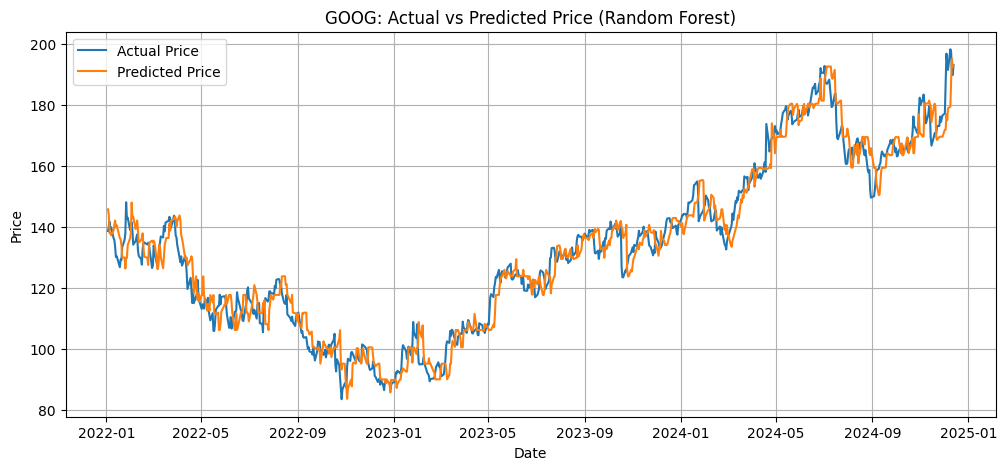

In [ ]:
# Trực quan hóa kết quả
plt.figure(figsize=(12, 5))

plt.plot(goog_df['Date'], goog_df['Future_Close'], label='Actual Price')

plt.plot(goog_df['Date'], goog_df['Predicted_Close'], label='Predicted Price')

plt.title('GOOG: Actual vs Predicted Price (Random Forest)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


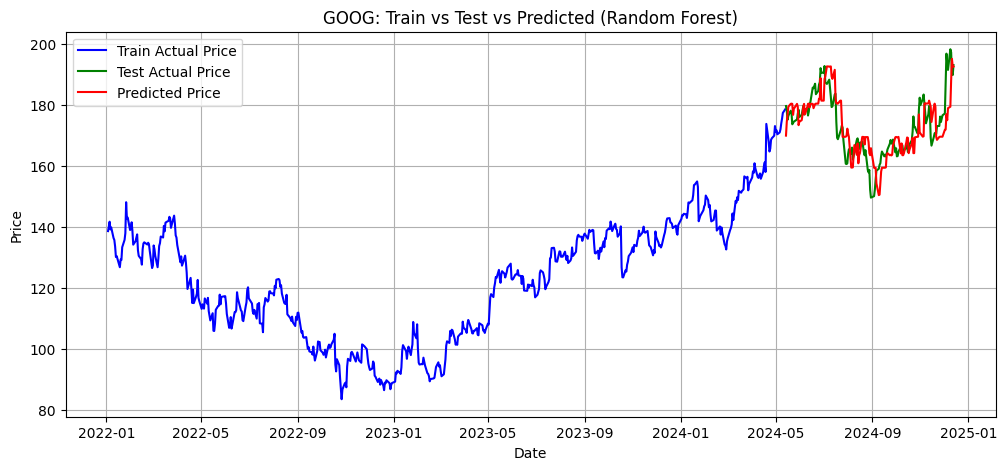

In [ ]:
train_size = int(len(goog_df) * 0.8)

train_df = goog_df.iloc[:train_size]
test_df  = goog_df.iloc[train_size:]

plt.figure(figsize=(12, 5))

# Train (Actual)
plt.plot(train_df['Date'], train_df['Future_Close'], label='Train Actual Price',color='blue' )

# Test (Actual)
plt.plot(test_df['Date'], test_df['Future_Close'],label='Test Actual Price',color='green')

# Test (Predicted)
plt.plot(test_df['Date'],test_df['Predicted_Close'],label='Predicted Price',color='red')

plt.title('GOOG: Train vs Test vs Predicted (Random Forest)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


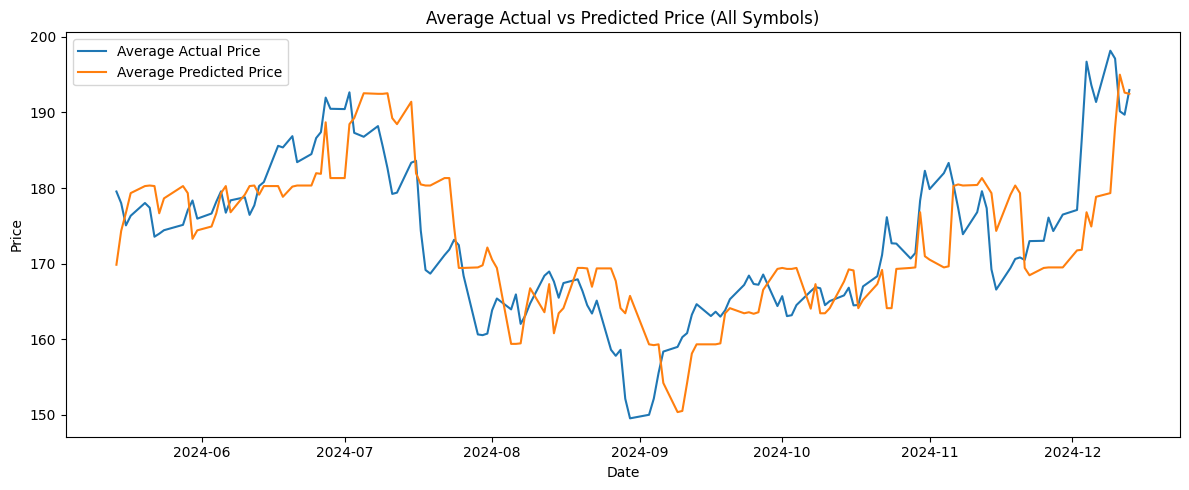

In [ ]:
avg_df = test_df.groupby('Date')[['Future_Close', 'Predicted_Close']].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(avg_df['Date'], avg_df['Future_Close'], label='Average Actual Price')
plt.plot(avg_df['Date'], avg_df['Predicted_Close'], label='Average Predicted Price')

plt.title("Average Actual vs Predicted Price (All Symbols)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-2701280262.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Error'] = test_df['Predicted_Close'] - test_df['Future_Close']


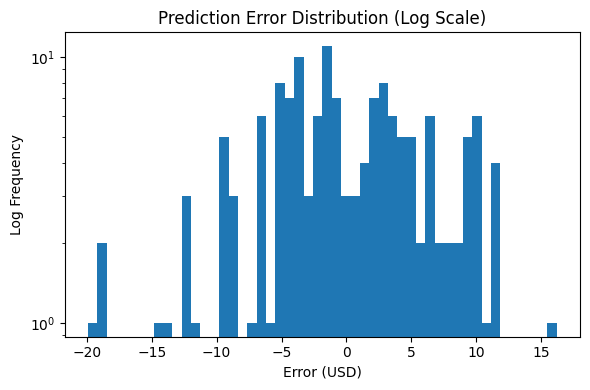

In [ ]:
test_df['Error'] = test_df['Predicted_Close'] - test_df['Future_Close']

plt.figure(figsize=(6,4))
plt.hist(test_df['Error'], bins=50, log=True)
plt.title("Prediction Error Distribution (Log Scale)")
plt.xlabel("Error (USD)")
plt.ylabel("Log Frequency")
plt.tight_layout()
plt.show()



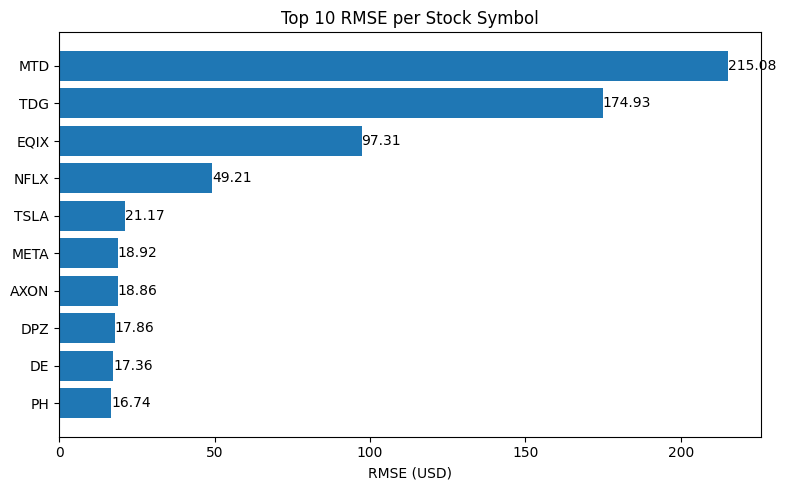

In [ ]:
rmse_top10 = metrics_df.sort_values('RMSE', ascending=False).head(10)

plt.figure(figsize=(8, 5))
bars = plt.barh(rmse_top10['Symbol'], rmse_top10['RMSE'])

plt.xlabel("RMSE (USD)")
plt.title("Top 10 RMSE per Stock Symbol")
plt.gca().invert_yaxis()

for bar in bars:
  plt.text(
    bar.get_width(),
    bar.get_y() + bar.get_height() / 2,
    f"{bar.get_width():.2f}",
    va='center',
    ha='left'
  )

plt.tight_layout()
plt.show()


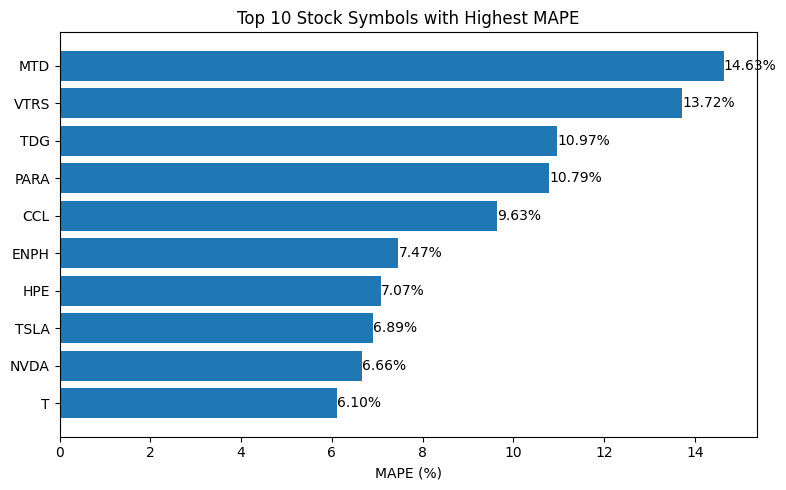

In [ ]:
# Sort theo MAPE giảm dần
mape_top10 = metrics_df.sort_values('MAPE', ascending=False).head(10)

plt.figure(figsize=(8, 5))
bars = plt.barh(mape_top10['Symbol'], mape_top10['MAPE'])

plt.xlabel("MAPE (%)")
plt.title("Top 10 Stock Symbols with Highest MAPE")
plt.gca().invert_yaxis()

# Ghi giá trị MAPE trên từng thanh
for bar in bars:
  plt.text(
      bar.get_width(),
      bar.get_y() + bar.get_height() / 2,
      f"{bar.get_width():.2f}%",
      va='center',
      ha='left'
  )

plt.tight_layout()
plt.show()


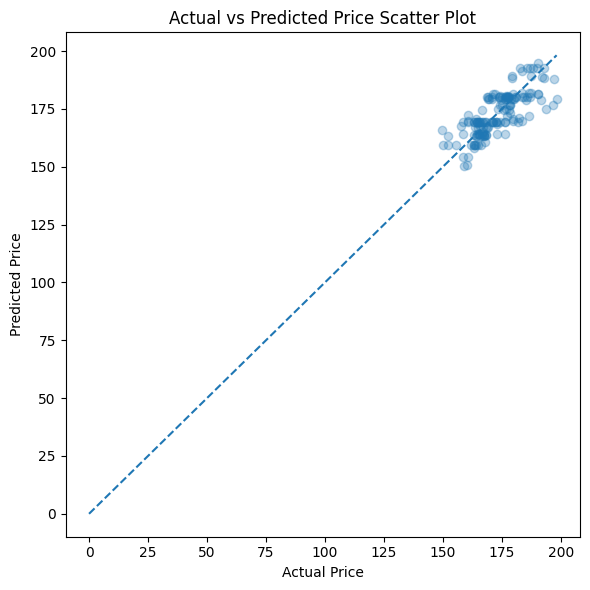

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(test_df['Future_Close'], test_df['Predicted_Close'], alpha=0.3)

max_price = max(test_df['Future_Close'].max(), test_df['Predicted_Close'].max())
plt.plot([0, max_price], [0, max_price], '--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price Scatter Plot")
plt.tight_layout()
plt.show()
